# 03 — Group Comparison
Compare two WhatsApp groups side by side: topic distribution,
activity patterns and sentiment.

> `comparator.py` is not yet implemented — `GroupComparator` is simulated
> with synthetic data that mirrors the expected output shape.

## 0 · Setup

In [1]:
import os, sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120
print("Ready.")

Ready.


## 1 · Synthetic group data

In [2]:
rng = np.random.default_rng(7)
TOPICS = ["Travail", "Organisation", "Social", "Actualités", "Divers"]
GROUPS = ["Group_A", "Group_B"]
AUTHORS = {
    "Group_A": ["Aminata", "Moussa", "Fatou"],
    "Group_B": ["Ibrahima", "Mariama", "Oumar"],
}

def make_group_df(group_name: str, n: int = 150) -> pd.DataFrame:
    """Build a synthetic analysis DataFrame for one group."""
    timestamps = pd.date_range("2024-01-01 08:00", periods=n, freq="3h")
    authors = AUTHORS[group_name]
    return pd.DataFrame({
        "timestamp"      : rng.choice(timestamps, size=n),
        "author"         : rng.choice(authors, size=n),
        "message"        : [f"msg {i}" for i in range(n)],
        "topic_label"    : rng.choice(TOPICS, size=n,
                            p=[0.35, 0.25, 0.20, 0.12, 0.08]
                            if group_name == "Group_A"
                            else [0.10, 0.20, 0.35, 0.15, 0.20]),
        "sentiment_score": rng.uniform(-1, 1, size=n).round(2),
        "group_name"     : group_name,
    })

df_a = make_group_df("Group_A")
df_b = make_group_df("Group_B")

print("Group_A:", len(df_a), "messages |", df_a["author"].nunique(), "authors")
print("Group_B:", len(df_b), "messages |", df_b["author"].nunique(), "authors")

Group_A: 150 messages | 3 authors
Group_B: 150 messages | 3 authors


## 2 · GroupComparator (simulated)

In [3]:
# Mirrors the expected output of GroupComparator.compare()
comparison = {
    "groups": GROUPS,
    "message_counts": {
        g: len(df) for g, df in [("Group_A", df_a), ("Group_B", df_b)]
    },
    "author_counts": {
        g: df["author"].nunique()
        for g, df in [("Group_A", df_a), ("Group_B", df_b)]
    },
    "sentiment_means": {
        g: round(float(df["sentiment_score"].mean()), 3)
        for g, df in [("Group_A", df_a), ("Group_B", df_b)]
    },
}

# Comparison table
summary = pd.DataFrame({
    "Metric": ["Messages", "Authors", "Sentiment mean"],
    "Group_A": [
        comparison["message_counts"]["Group_A"],
        comparison["author_counts"]["Group_A"],
        comparison["sentiment_means"]["Group_A"],
    ],
    "Group_B": [
        comparison["message_counts"]["Group_B"],
        comparison["author_counts"]["Group_B"],
        comparison["sentiment_means"]["Group_B"],
    ],
})
summary

,Metric,Group_A,Group_B
0,Messages,150.000,150.000
1,Authors,3.000,3.000
2,Sentiment mean,0.025,-0.094


## 3 · Side-by-side topic distribution

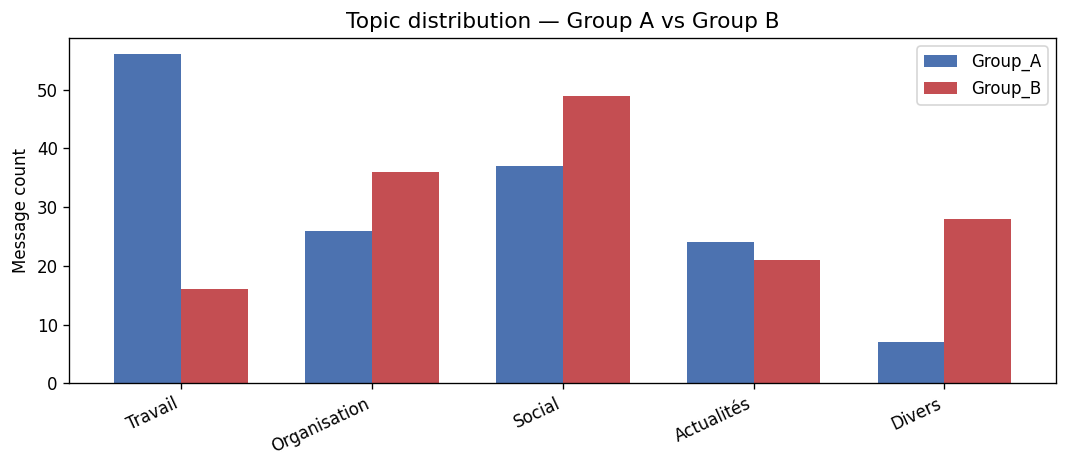

In [4]:
topic_a = df_a["topic_label"].value_counts().reindex(TOPICS, fill_value=0)
topic_b = df_b["topic_label"].value_counts().reindex(TOPICS, fill_value=0)
topic_df = pd.DataFrame({"Group_A": topic_a, "Group_B": topic_b})

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(TOPICS))
width = 0.35
bars_a = ax.bar([i - width/2 for i in x], topic_df["Group_A"],
                width=width, label="Group_A", color="#4C72B0")
bars_b = ax.bar([i + width/2 for i in x], topic_df["Group_B"],
                width=width, label="Group_B", color="#C44E52")
ax.set_xticks(list(x))
ax.set_xticklabels(TOPICS, rotation=25, ha="right")
ax.set_ylabel("Message count")
ax.set_title("Topic distribution — Group A vs Group B", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## 4 · Activity timeline comparison

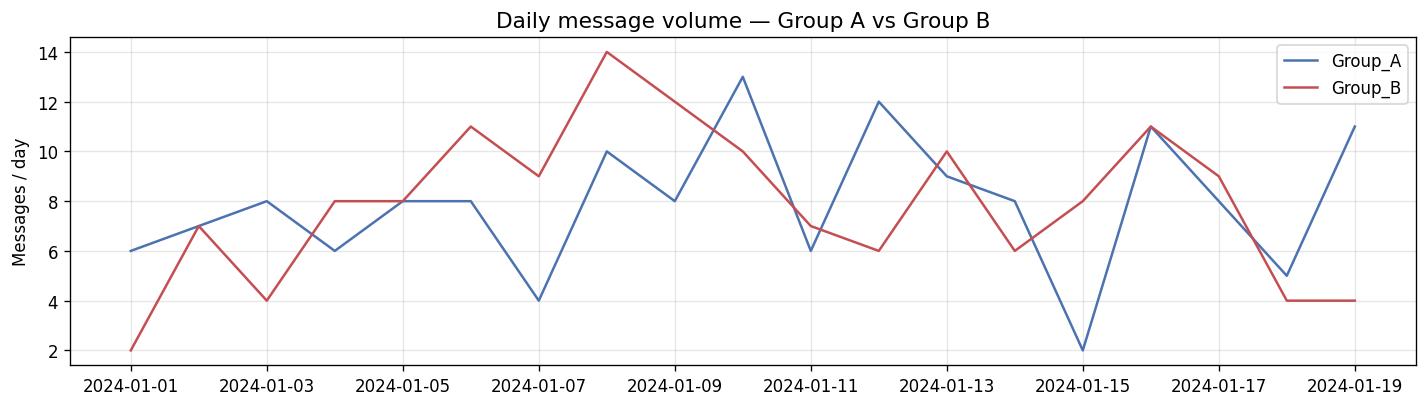

In [5]:
df_a["date"] = pd.to_datetime(df_a["timestamp"]).dt.date
df_b["date"] = pd.to_datetime(df_b["timestamp"]).dt.date

timeline_a = df_a.groupby("date").size().rename("Group_A")
timeline_b = df_b.groupby("date").size().rename("Group_B")
timeline = pd.concat([timeline_a, timeline_b], axis=1).fillna(0)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(pd.to_datetime(timeline.index), timeline["Group_A"],
        label="Group_A", color="#4C72B0", linewidth=1.5)
ax.plot(pd.to_datetime(timeline.index), timeline["Group_B"],
        label="Group_B", color="#C44E52", linewidth=1.5)
ax.set_title("Daily message volume — Group A vs Group B", fontsize=13)
ax.set_ylabel("Messages / day")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5 · Sentiment comparison

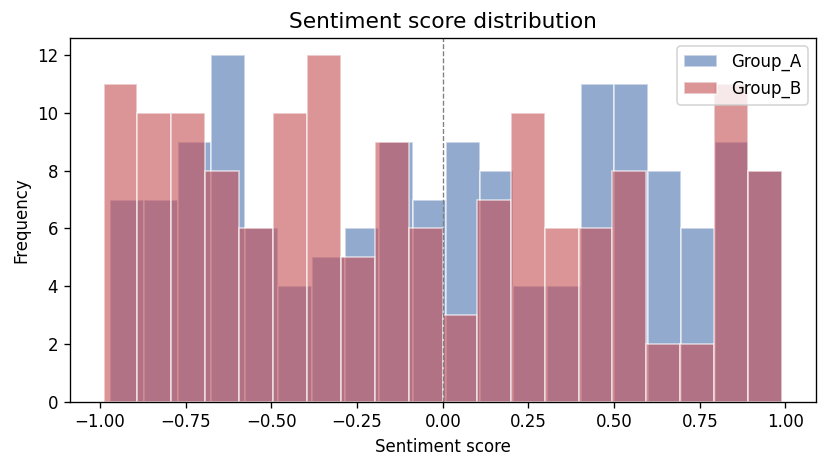

In [6]:
sent = pd.DataFrame({
    "Group": ["Group_A"] * len(df_a) + ["Group_B"] * len(df_b),
    "sentiment_score": pd.concat([df_a["sentiment_score"], df_b["sentiment_score"]]).values,
})

fig, ax = plt.subplots(figsize=(7, 4))
for group, color in zip(GROUPS, ["#4C72B0", "#C44E52"]):
    sub = sent[sent["Group"] == group]["sentiment_score"]
    ax.hist(sub, bins=20, alpha=0.6, label=group, color=color, edgecolor="white")
ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Sentiment score distribution", fontsize=13)
ax.set_xlabel("Sentiment score")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()